# Non-Curated 

**(Minimal QA - Just Process Everything)**

Minimal QA pipeline - the quick and dirty approach
- Valid mask: Only pixels where both bands > 0 are processed
- Basic cloud mask

What get's skipped:
- Cloud mask validation / refinement
- Atmospheric correction QA
- Co-registration checks
- Outlier removal
- Edge artifacts handling

Sentinel-2 L2A bands are scaled surface reflectanc (x10000) store as integers, not raw DN


## Basic cloud mask using high-confidence clouds

In [35]:
import os
import numpy as np
import rasterio

In [34]:
# ─── 1. Directorios ────────────────────────────────────────
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, r'output\non_qa')
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PREFIRE_DIR = os.path.join(DATA_DIR, 'prefire')
DATA_POSTFIRE_DIR = os.path.join(DATA_DIR, 'postfire')
OUT_PREFIRE_DIR = os.path.join(OUTPUT_DIR, 'prefire')
OUT_POSTFIRE_DIR = os.path.join(OUTPUT_DIR, 'postfire')


AOI_PATH = os.path.join(DATA_DIR, 'aoi.geojson')

# ─── 2. Rutas corregidas (ejemplo 2025-08-01 y 2025-08-23) ───
clip_pre = {
    'B04': os.path.join(DATA_PREFIRE_DIR, 'clip_red.tiff'),
    'B8A': os.path.join(DATA_PREFIRE_DIR, 'clip_nir.tiff'),
    'B12': os.path.join(DATA_PREFIRE_DIR, 'clip_swir2.tiff'),
    'SCL': os.path.join(DATA_PREFIRE_DIR, 'clip_scl.tiff'),
    'AOT': os.path.join(DATA_PREFIRE_DIR, 'clip_aot.tiff'),
    'WVP': os.path.join(DATA_PREFIRE_DIR, 'clip_wvp.tiff')
}

clip_post = {
    'B04': os.path.join(DATA_POSTFIRE_DIR, 'clip_red.tiff'),
    'B8A': os.path.join(DATA_POSTFIRE_DIR, 'clip_nir.tiff'),
    'B12': os.path.join(DATA_POSTFIRE_DIR, 'clip_swir2.tiff'),
    'SCL': os.path.join(DATA_POSTFIRE_DIR, 'clip_scl.tiff'),
    'AOT': os.path.join(DATA_POSTFIRE_DIR, 'clip_aot.tiff'),
    'WVP': os.path.join(DATA_POSTFIRE_DIR, 'clip_wvo.tiff')
}


NBR_PRE  = os.path.join(OUT_PREFIRE_DIR, 'nbr_pre.tif')
NBR_POST = os.path.join(OUT_POSTFIRE_DIR, 'nbr_post.tif')

CLOUD_PRE = os.path.join(OUT_PREFIRE_DIR, 'cloud_pre.tif')
CLOUD_POST = os.path.join(OUT_POSTFIRE_DIR, 'cloud_post.tif')

In [36]:
def basic_cloud_mask(scl_path, out_path):
        """
        Basic cloud mask using only high-confidence clouds
        """
        # SCL values:
        # 8 = Cloud medium probability
        # 9 = Cloud high probability
        # 10 = Thin cirrus
        # 3 = Cloud shadows

        with rasterio.open(scl_path) as src:
                scl = src.read(1)
                meta = src.meta.copy()
         
        # Non-curated: Only mask high-confidence clouds
        cloud_mask = np.isin(scl, [9, 10]).astype(np.uint8)  # Skip medium prob clouds and shadows!

        cloud_fraction = np.sum(cloud_mask) / cloud_mask.size
        print(f"  Cloud fraction: {cloud_fraction:.1%}")

        meta.update({
        "count": 1,
        "dtype": "uint8",
        "nodata": 0
        })

        with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(cloud_mask, 1)
        
        return cloud_mask

In [37]:
cloud_pre = basic_cloud_mask(
    clip_pre['SCL'], 
    CLOUD_PRE
)

cloud_post = basic_cloud_mask(
    clip_post['SCL'], 
    CLOUD_POST
)

  Cloud fraction: 0.0%
  Cloud fraction: 0.0%


In [46]:
def basic_nbr(b8a_path, b12_path, basic_cloud_mask_path, out_path):
        """
        Calculate NBR without additional QA
        """
        print("\nCalculating NBR (non-curated)...")
        
        with rasterio.open(b8a_path) as src:
                b8a = src.read(1).astype("float32") / 10000.0
                meta = src.meta.copy()
        
        with rasterio.open(b12_path) as src:
                b12 = src.read(1).astype("float32") / 10000.0

        with rasterio.open(basic_cloud_mask_path) as src:
                basic_cloud_mask = src.read(1).astype(np.uint8)
        
        #Valid mask: both bands > 0
        valid_mask = (b8a > 0) & (b12 > 0)
        nbr = np.full(b8a.shape, -9999, dtype = "float32")
        nbr[valid_mask] = (b8a[valid_mask] - b12[valid_mask]) / (b8a[valid_mask] + b12[valid_mask] + 1e-10)
             
        # Simple calculation - no validation
        #nbr = (b8a - b12) / (b8a + b12 + 1e-10)
        
        # Apply cloud mask
        nbr[basic_cloud_mask] = np.nan

        meta.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": "float32",
        "nodata": -9999.0
        })
        
        # Check for issues (but don't fix them)
        invalid_count = np.sum(np.isnan(nbr) | np.isinf(nbr))
        if invalid_count > 0:
            print(f"  ⚠️  Warning: {invalid_count} invalid pixels (not addressed)")
        
        # Replace NaN with nodata before writing
        nbr_out = np.where(np.isnan(nbr), meta["nodata"], nbr).astype(np.float32)

        with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(nbr_out, 1)
        
        return nbr

In [47]:
nbr_pre = basic_nbr(
    clip_pre['B8A'], 
    clip_pre['B12'], 
    clip_pre['SCL'],
    NBR_PRE 
)

nbr_post = basic_nbr(
    clip_post['B8A'], 
    clip_post['B12'], 
    clip_post['SCL'], 
    NBR_POST
)


Calculating NBR (non-curated)...
  ⚠️  Warning: 8634 invalid pixels (not addressed)

Calculating NBR (non-curated)...
  ⚠️  Warning: 8634 invalid pixels (not addressed)


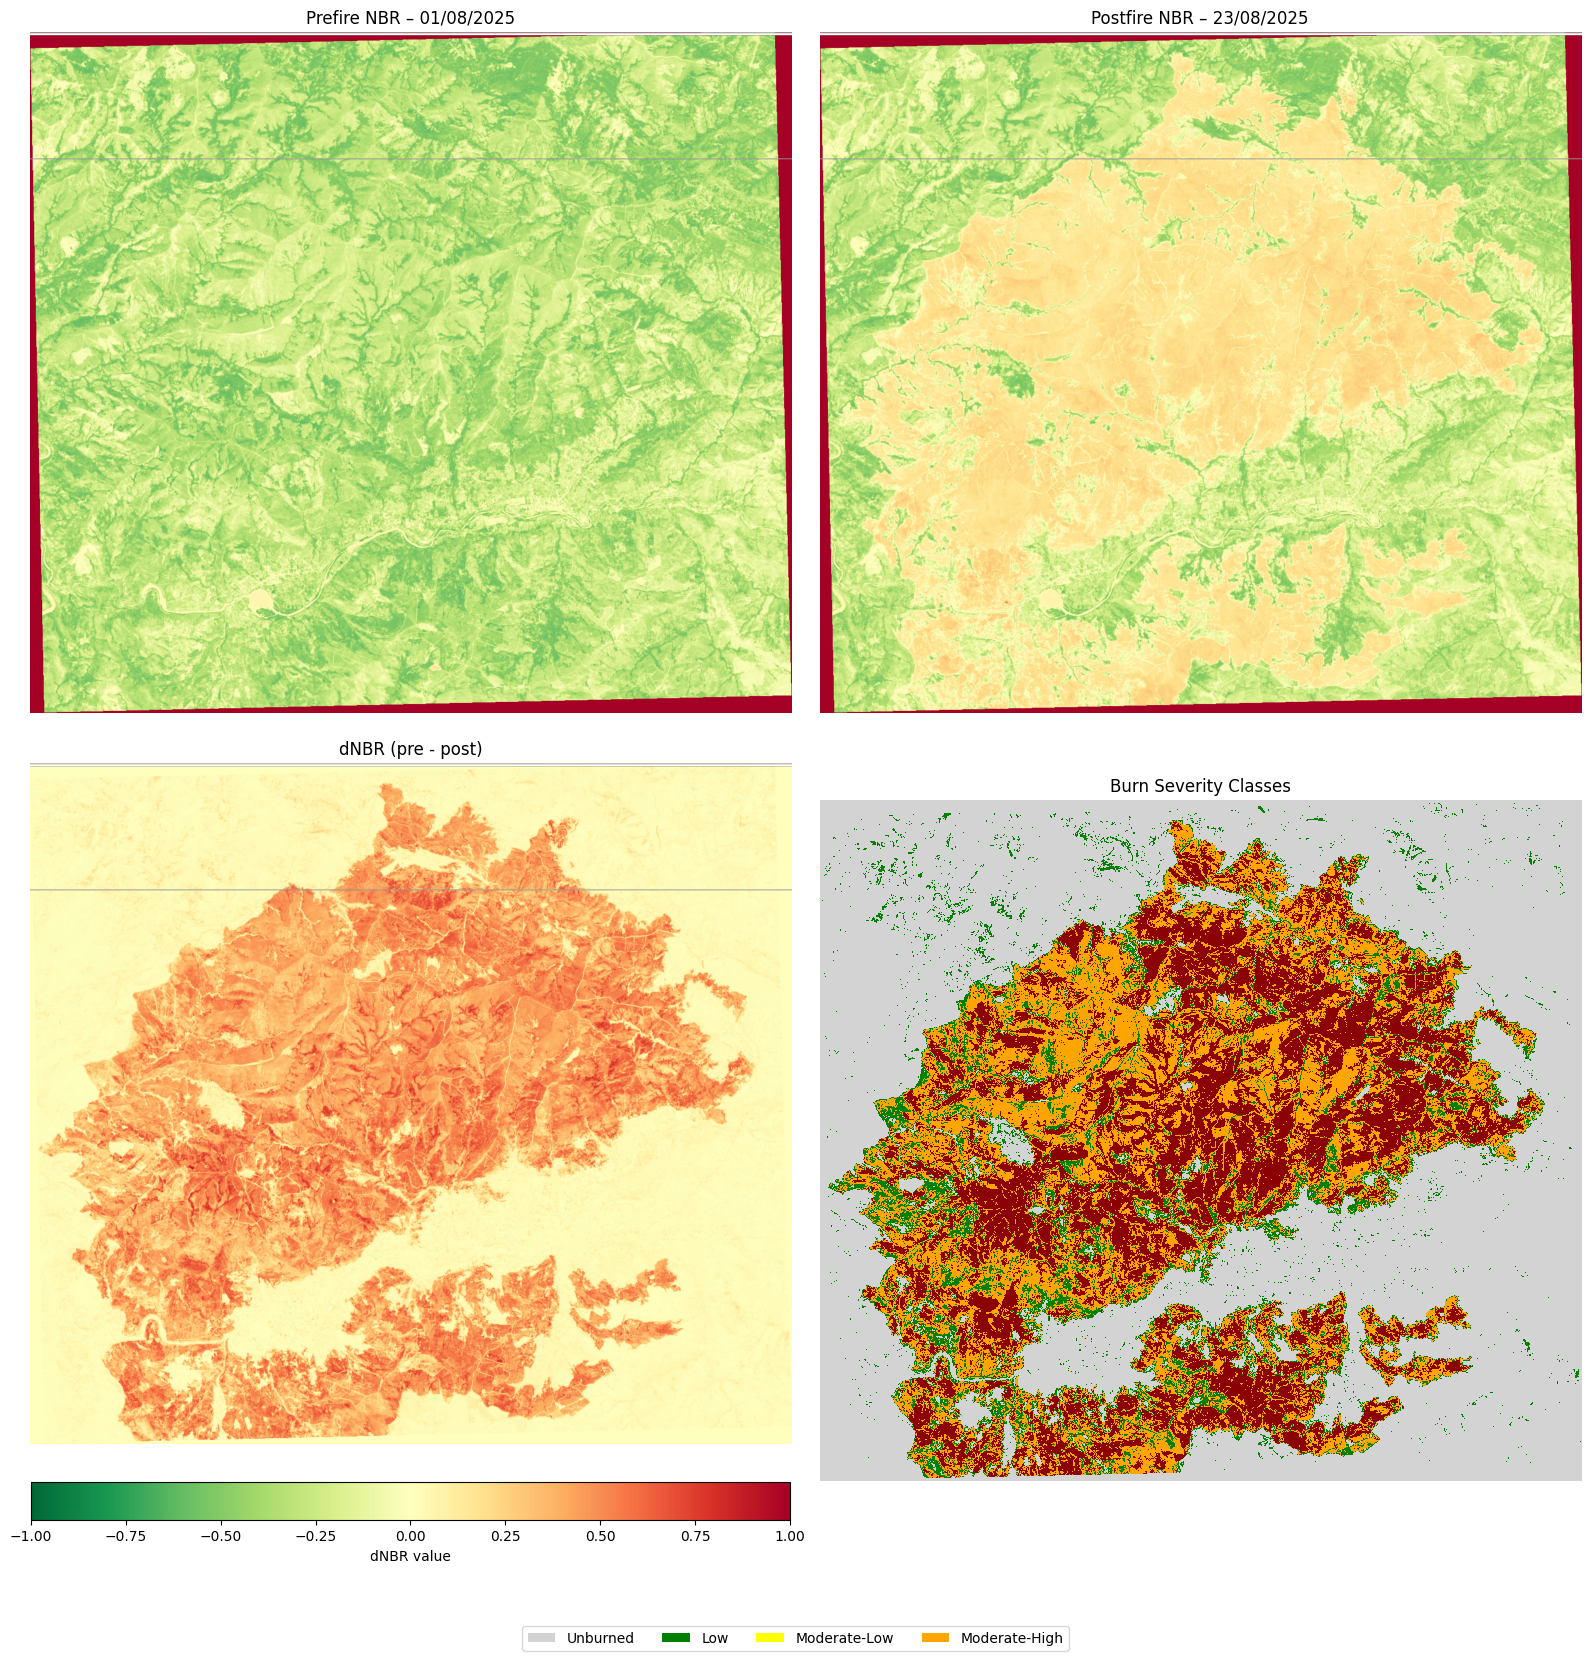

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assuming nbr_pre and nbr_post are already loaded as 2D numpy arrays 
# (from your earlier code, valid pixels only, values in [-1,1] range)

# 1. Compute dNBR
dnbr = nbr_pre - nbr_post

# 2. Create severity classification array
severity = np.full_like(dnbr, 0, dtype=np.uint8)  # 0 = unburned/low/no change

severity[(dnbr < 0.10)] = 0 # Unburned
severity[(dnbr >= 0.1)  & (dnbr < 0.27)] = 1  # Low severity
severity[(dnbr >= 0.27) & (dnbr < 0.44)] = 2  # Moderate-Low severity
severity[(dnbr >= 0.44) & (dnbr < 0.66)] = 3  # Moderate-High severity
severity[(dnbr > 0.66)] = 4 # High severity

# Optional: mask out invalid/negative dNBR if needed (e.g. from clouds/edges)
# severity[dnbr < -0.5] = np.nan  # or handle separately

# 3. Define a nice colormap for severity (gray → yellow → orange → red)
severity_cmap = ListedColormap(['lightgray', 'green', 'yellow', 'orange', 'darkred'])
severity_labels = ['Unburned', 'Low', 'Moderate-Low', 'Moderate-High', 'High']

# 4. Plot: pre-NBR, post-NBR, dNBR, and severity map
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Prefire NBR
axes[0,0].imshow(nbr_pre, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0,0].set_title("Prefire NBR – 01/08/2025")
axes[0,0].axis('off')

# Postfire NBR
axes[0,1].imshow(nbr_post, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0,1].set_title("Postfire NBR – 23/08/2025")
axes[0,1].axis('off')

# Continuous dNBR (reversed so positive = red = burn)
im_dnbr = axes[1,0].imshow(dnbr, cmap='RdYlGn_r', vmin=-1, vmax=1)
axes[1,0].set_title("dNBR (pre - post)")
axes[1,0].axis('off')

# Severity classes
im_sev = axes[1,1].imshow(severity, cmap=severity_cmap, vmin=0, vmax=3, interpolation='nearest')
axes[1,1].set_title("Burn Severity Classes")
axes[1,1].axis('off')

# Shared colorbar for dNBR
cbar_dnbr = fig.colorbar(im_dnbr, ax=axes[1,0], orientation='horizontal', fraction=0.05, pad=0.05)
cbar_dnbr.set_label('dNBR value')

# Legend for severity (manual, since discrete)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=severity_cmap(i), label=severity_labels[i]) for i in range(4)]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout()
plt.show()